# MJD Transformer Results

Loads completed run artifacts only. This notebook never prepares data or trains/evaluates a model.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUT_ROOT = Path(
    '/home/klz/Data/zeronu_benchmark/Transformer_Approach/'
    'mjd_detector/results/transformer_official_v1'
)
SUMMARY_PATH = OUTPUT_ROOT / 'transformer_results.csv'
print('Results:', OUTPUT_ROOT)

Results: /home/klz/Data/zeronu_benchmark/Transformer_Approach/mjd_detector/results/transformer_official_v1


In [2]:
def load_completed_runs(output_root):
    rows = []
    for run_dir in sorted(output_root.iterdir() if output_root.is_dir() else []):
        summary_path = run_dir / 'run_summary.json'
        if summary_path.is_file():
            rows.append(json.loads(summary_path.read_text(encoding='utf-8')))
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['task', 'tokenization', 'position_encoding']
    ).reset_index(drop=True)

results = load_completed_runs(OUTPUT_ROOT)
if results.empty and SUMMARY_PATH.is_file():
    results = pd.read_csv(SUMMARY_PATH)

expected_runs = 12
print(f'Completed runs: {len(results)}/{expected_runs}')
display(results)

Completed runs: 12/12


,run_id,task,tokenization,position_encoding,parameter_count,train_events,validation_events,test_events,epochs_completed,best_epoch,best_validation_score,training_seconds,minutes_per_epoch,evaluation_seconds,test_auc,test_accuracy,test_mae_kev,test_rmse_kev,test_bias_kev,test_loss
0,classification__pulse_entities__coordinate_mlp,classification,pulse_entities,coordinate_mlp,111105,936000,104000,390000,32,27,0.932519,39806.352543,20.732475,355.447236,0.933425,0.856590,NaN,NaN,NaN,0.306631
1,classification__pulse_entities__fourier_coordi...,classification,pulse_entities,fourier_coordinates,113409,936000,104000,390000,28,23,0.944066,35291.336628,21.006748,441.302560,0.944452,0.868518,NaN,NaN,NaN,0.282995
2,classification__raw_patches__coordinate_mlp,classification,raw_patches,coordinate_mlp,112257,936000,104000,390000,50,46,0.973894,16938.540261,5.646180,76.478796,0.974491,0.916733,NaN,NaN,NaN,0.197765
3,classification__raw_patches__fourier_coordinates,classification,raw_patches,fourier_coordinates,114561,936000,104000,390000,49,44,0.981123,15698.111831,5.339494,76.703532,0.981495,0.927854,NaN,NaN,NaN,0.176425
4,classification__segment_summary__coordinate_mlp,classification,segment_summary,coordinate_mlp,111105,936000,104000,390000,36,31,0.966501,18932.468532,8.765032,118.902973,0.967016,0.904849,NaN,NaN,NaN,0.221151
5,classification__segment_summary__fourier_coord...,classification,segment_summary,fourier_coordinates,113409,936000,104000,390000,28,23,0.970253,33275.812712,19.807031,299.004448,0.970892,0.912754,NaN,NaN,NaN,0.203295
6,regression__pulse_entities__coordinate_mlp,regression,pulse_entities,coordinate_mlp,111105,355796,39533,148251,21,16,53.836124,11798.536693,9.363918,155.670483,NaN,NaN,15.038597,53.307583,4.714835,2841.043533
7,regression__pulse_entities__fourier_coordinates,regression,pulse_entities,fourier_coordinates,113409,355796,39533,148251,13,8,47.623348,7280.014150,9.333351,158.227824,NaN,NaN,18.623940,44.363903,-7.158234,1967.801535
8,regression__raw_patches__coordinate_mlp,regression,raw_patches,coordinate_mlp,112257,355796,39533,148251,15,10,21.900526,5293.493804,5.881660,105.889745,NaN,NaN,9.673210,24.197121,-1.485877,585.408059
9,regression__raw_patches__fourier_coordinates,regression,raw_patches,fourier_coordinates,114561,355796,39533,148251,28,23,21.043751,9886.110560,5.884590,106.082169,NaN,NaN,9.995461,22.221966,5.594021,493.723317


In [3]:
if results.empty:
    print('No completed runs yet.')
else:
    classification_columns = [
        'tokenization', 'position_encoding', 'test_auc', 'test_accuracy',
        'best_epoch', 'epochs_completed', 'minutes_per_epoch',
        'parameter_count', 'test_events',
    ]
    regression_columns = [
        'tokenization', 'position_encoding', 'test_rmse_kev', 'test_mae_kev',
        'test_bias_kev', 'best_epoch', 'epochs_completed',
        'minutes_per_epoch', 'parameter_count', 'test_events',
    ]
    classification = results.loc[results['task'] == 'classification'].copy()
    regression = results.loc[results['task'] == 'regression'].copy()
    if not classification.empty:
        classification = classification.sort_values('test_auc', ascending=False)
        print('Classification — higher AUC is better')
        display(classification[classification_columns])
    if not regression.empty:
        regression = regression.sort_values('test_rmse_kev', ascending=True)
        print('Regression — lower RMSE is better')
        display(regression[regression_columns])

Classification — higher AUC is better


,tokenization,position_encoding,test_auc,test_accuracy,best_epoch,epochs_completed,minutes_per_epoch,parameter_count,test_events
3,raw_patches,fourier_coordinates,0.981495,0.927854,44,49,5.339494,114561,390000
2,raw_patches,coordinate_mlp,0.974491,0.916733,46,50,5.646180,112257,390000
5,segment_summary,fourier_coordinates,0.970892,0.912754,23,28,19.807031,113409,390000
4,segment_summary,coordinate_mlp,0.967016,0.904849,31,36,8.765032,111105,390000
1,pulse_entities,fourier_coordinates,0.944452,0.868518,23,28,21.006748,113409,390000
0,pulse_entities,coordinate_mlp,0.933425,0.856590,27,32,20.732475,111105,390000


Regression — lower RMSE is better


,tokenization,position_encoding,test_rmse_kev,test_mae_kev,test_bias_kev,best_epoch,epochs_completed,minutes_per_epoch,parameter_count,test_events
9,raw_patches,fourier_coordinates,22.221966,9.995461,5.594021,23,28,5.884590,114561,148251
8,raw_patches,coordinate_mlp,24.197121,9.673210,-1.485877,10,15,5.881660,112257,148251
11,segment_summary,fourier_coordinates,24.584166,9.558511,3.059135,8,13,8.353915,113409,148251
10,segment_summary,coordinate_mlp,34.390846,14.663388,8.356632,22,27,8.366833,111105,148251
7,pulse_entities,fourier_coordinates,44.363903,18.623940,-7.158234,8,13,9.333351,113409,148251
6,pulse_entities,coordinate_mlp,53.307583,15.038597,4.714835,16,21,9.363918,111105,148251


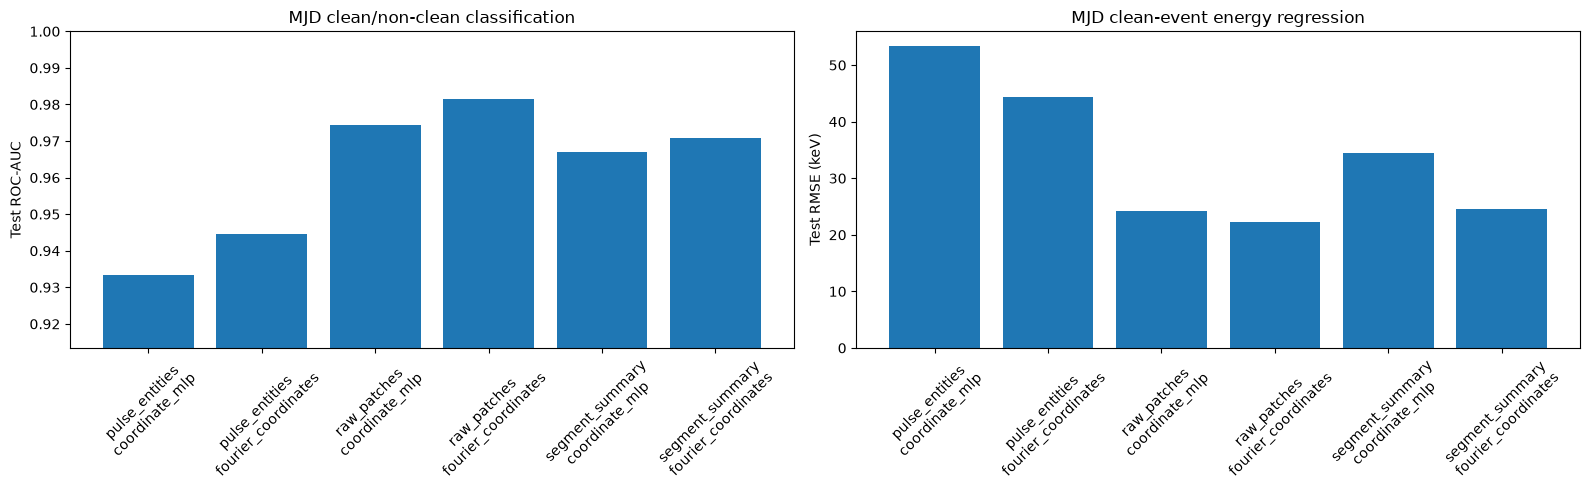

In [ ]:
if not results.empty:
    plot_data = results.copy()
    plot_data['representation'] = (
        plot_data['tokenization'] + '\n' + plot_data['position_encoding']
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    classification_plot = plot_data.loc[plot_data['task'] == 'classification']
    classification_plot['']
    regression_plot = plot_data.loc[plot_data['task'] == 'regression']
    if not classification_plot.empty:
        axes[0].bar(classification_plot['representation'], classification_plot['test_auc'])
        axes[0].set_title('MJD clean/non-clean classification')
        axes[0].set_ylabel('Test ROC-AUC')
        lower = max(0.0, float(classification_plot['test_auc'].min()) - 0.02)
        axes[0].set_ylim(lower, 1.0)
        axes[0].tick_params(axis='x', rotation=45)
    else:
        axes[0].set_visible(False)
    if not regression_plot.empty:
        axes[1].bar(regression_plot['representation'], regression_plot['test_rmse_kev'])
        axes[1].set_title('MJD clean-event energy regression')
        axes[1].set_ylabel('Test RMSE (keV)')
        axes[1].tick_params(axis='x', rotation=45)
    else:
        axes[1].set_visible(False)
    fig.tight_layout()
    plt.show()

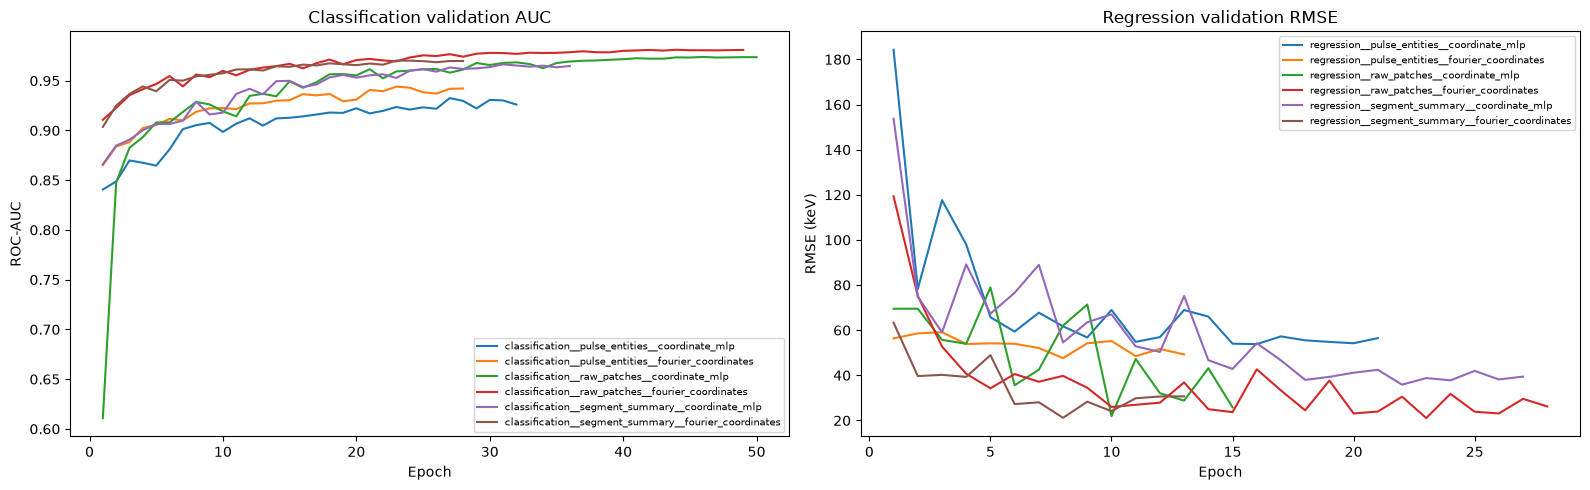

In [5]:
history_rows = []
for run_dir in sorted(OUTPUT_ROOT.iterdir() if OUTPUT_ROOT.is_dir() else []):
    history_path = run_dir / 'history.json'
    config_path = run_dir / 'run_config.json'
    if not history_path.is_file() or not config_path.is_file():
        continue
    history = json.loads(history_path.read_text(encoding='utf-8'))
    config = json.loads(config_path.read_text(encoding='utf-8'))
    for epoch in history:
        metrics = epoch['validation_metrics']
        history_rows.append({
            'run_id': config['run_id'],
            'task': config['task'],
            'epoch': epoch['epoch'],
            'validation_loss': epoch['validation_loss'],
            'validation_auc': metrics.get('macro_auc'),
            'validation_rmse_kev': metrics.get('rmse_kev'),
        })
history_table = pd.DataFrame(history_rows)

if not history_table.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    classification_history = history_table.loc[history_table['task'] == 'classification']
    regression_history = history_table.loc[history_table['task'] == 'regression']
    for run_id, group in classification_history.groupby('run_id'):
        axes[0].plot(group['epoch'], group['validation_auc'], label=run_id)
    axes[0].set_title('Classification validation AUC')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('ROC-AUC')
    if not classification_history.empty:
        axes[0].legend(fontsize=7)
    for run_id, group in regression_history.groupby('run_id'):
        axes[1].plot(group['epoch'], group['validation_rmse_kev'], label=run_id)
    axes[1].set_title('Regression validation RMSE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('RMSE (keV)')
    if not regression_history.empty:
        axes[1].legend(fontsize=7)
    fig.tight_layout()
    plt.show()